# Notebook 05 — Energy Scenario: Pass-Through Analysis

**Goal:** Quantify the impact of energy price shocks (2026 Iran scenario) on restaurant margins  
via a calibrated pass-through chain.

**Chain:**
```
energy_price → Δ% energia vs baseline
             → Δ% prezzo menu  (pass-through rate × Δ% energia)
             → margin_compression_eur/day  (absorbed shock net of menu adjustment)
```

**Sections:**
- Phase A — Historical calibration (FIPE 2022)
- Phase B — Scenario analysis (3 PUN levels)
- Phase C — Historical PUN chart + scenario thresholds
- Phase D — Demand response *(to be modelled — pending)*

In [1]:
import sys
from pathlib import Path

_project_root = next(p for p in [Path.cwd(), Path.cwd().parent] if (p / 'src').exists())
for _p in [str(_project_root), str(_project_root / 'src')]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

print('Libraries loaded.')

Libraries loaded.


In [2]:
# --- Load data ---
df = pd.read_csv(
    _project_root / 'data/processed/daily_timeseries.csv',
    parse_dates=['date']
).sort_values('date').reset_index(drop=True)

dim_energy = pd.read_csv(
    _project_root / 'data/external/dim_energy.csv',
    parse_dates=['date']
).sort_values('date').reset_index(drop=True)

REVENUE_MEAN = df['revenue'].mean().round(2)

print(f'Timeseries  : {df.shape[0]} rows  ({df["date"].min().date()} → {df["date"].max().date()})')
print(f'dim_energy  : {dim_energy.shape[0]} rows  ({dim_energy["date"].min().date()} → {dim_energy["date"].max().date()})')
print(f'Revenue mean (daily, food-only): {REVENUE_MEAN} EUR')
print(f'PUN mean 2023-2024            : {dim_energy["pun_eur_mwh"].mean():.2f} EUR/MWh')

Timeseries  : 731 rows  (2023-01-01 → 2024-12-31)
dim_energy  : 731 rows  (2023-01-01 → 2024-12-31)
Revenue mean (daily, food-only): 1940.14 EUR
PUN mean 2023-2024            : 117.87 EUR/MWh


---
## Phase A — Historical Calibration (FIPE 2022)

Validate the pass-through rate using the 2022 Italian energy crisis data (source: FIPE).

| Metric | Value |
|--------|-------|
| Energy price shock (2022) | +200% |
| Menu price increase (2022) | +5% |
| **Implied pass-through rate** | **5% / 200% = 0.025** |
| Share absorbed by margin | 97.5% |

Interpretation: for every 1% increase in energy costs, restaurants passed **2.5%** of that increase  
to menu prices and absorbed the remaining **97.5%** through margin compression.

In [3]:
# --- Phase A: Calibration parameters ---

# FIPE 2022 observed data
FIPE_ENERGY_SHOCK  = 2.00   # +200% energy price increase
FIPE_MENU_INCREASE = 0.05   # +5% menu price increase

# Derived pass-through rate
PASS_THROUGH_RATE = FIPE_MENU_INCREASE / FIPE_ENERGY_SHOCK

# 2026 baseline and energy share parameters
BASELINE_PUN        = 117.0   # EUR/MWh — GME average last 30 days
ENERGY_SHARE        = 0.12    # 12% energy share of revenue — HoReCa high-intensity estimate
                               # Source: operational estimate, range 10–15%

print('=' * 55)
print('  CALIBRATION — FIPE 2022')
print('=' * 55)
print(f'  Energy shock          : +{FIPE_ENERGY_SHOCK*100:.0f}%')
print(f'  Menu price increase   : +{FIPE_MENU_INCREASE*100:.1f}%')
print(f'  Pass-through rate     :  {PASS_THROUGH_RATE:.4f}  ({PASS_THROUGH_RATE*100:.2f}%)')
print(f'  Absorbed by margin    :  {(1-PASS_THROUGH_RATE)*100:.2f}%')
print('=' * 55)
print()
print('2026 model parameters:')
print(f'  Baseline PUN          :  {BASELINE_PUN} EUR/MWh')
print(f'  Energy share/revenue  :  {ENERGY_SHARE*100:.0f}%')
print(f'  Revenue mean (daily)  :  {REVENUE_MEAN} EUR/day')
print(f'  Energy cost (daily)   :  {REVENUE_MEAN * ENERGY_SHARE:.2f} EUR/day  (= {REVENUE_MEAN} × {ENERGY_SHARE})')

  CALIBRATION — FIPE 2022
  Energy shock          : +200%
  Menu price increase   : +5.0%
  Pass-through rate     :  0.0250  (2.50%)
  Absorbed by margin    :  97.50%

2026 model parameters:
  Baseline PUN          :  117.0 EUR/MWh
  Energy share/revenue  :  12%
  Revenue mean (daily)  :  1940.14 EUR/day
  Energy cost (daily)   :  232.82 EUR/day  (= 1940.14 × 0.12)


---
## Phase B — Scenario Analysis

Three PUN scenarios for 2026, based on Iran geopolitical shock trajectory.

| Scenario | PUN (€/MWh) | Description |
|----------|-------------|-------------|
| A | 150 | Tensione lieve — mercato teso ma contenuto |
| B | 250 | Shock moderato — interruzione parziale forniture |
| C | 300 | Shock severo — crisi prolungata |

**Pass-through chain per scenario:**
```
step 1 → Δ_energy  = (scenario_pun - baseline) / baseline
step 2 → Δ_menu    = Δ_energy × pass_through_rate
step 3 → margin_compression_eur = (energy_cost_daily × Δ_energy) - (revenue_mean × Δ_menu)
```

In [4]:
# --- Phase B: Scenario computation ---

SCENARIOS = {
    'A — Tensione lieve'  : 150,
    'B — Shock moderato'  : 250,
    'C — Shock severo'    : 300,
}

energy_cost_daily = REVENUE_MEAN * ENERGY_SHARE

rows = []
for label, pun in SCENARIOS.items():
    delta_energy       = (pun - BASELINE_PUN) / BASELINE_PUN
    delta_menu         = delta_energy * PASS_THROUGH_RATE
    delta_margin_pct   = delta_energy * (1 - PASS_THROUGH_RATE)

    energy_increase    = energy_cost_daily * delta_energy
    quota_trasferita   = REVENUE_MEAN * delta_menu
    margin_comp_day    = energy_increase - quota_trasferita
    margin_comp_year   = margin_comp_day * 365

    rows.append({
        'scenario'              : label,
        'pun_eur_mwh'           : pun,
        'delta_energy_pct'      : round(delta_energy * 100, 1),
        'delta_menu_pct'        : round(delta_menu * 100, 2),
        'delta_margin_abs_pct'  : round(delta_margin_pct * 100, 1),
        'margin_comp_eur_day'   : round(margin_comp_day, 2),
        'margin_comp_eur_year'  : round(margin_comp_year, 0),
    })

results = pd.DataFrame(rows)

# --- Print scenario summary ---
print('=' * 65)
print('  PASS-THROUGH ANALYSIS — 2026 SCENARIOS')
print(f'  Baseline PUN: {BASELINE_PUN} EUR/MWh  |  '
      f'Energy share: {ENERGY_SHARE*100:.0f}%  |  '
      f'Revenue mean: {REVENUE_MEAN} EUR/day')
print('=' * 65)
for _, row in results.iterrows():
    print(f"\n  Scenario {row['scenario']}  ({row['pun_eur_mwh']} EUR/MWh)")
    print(f"    Δ% energia vs baseline    : +{row['delta_energy_pct']:.1f}%")
    print(f"    Δ% prezzo menu            : +{row['delta_menu_pct']:.2f}%")
    print(f"    Δ% assorbito dal margine  : +{row['delta_margin_abs_pct']:.1f}%")
    print(f"    Compressione margine      :  {row['margin_comp_eur_day']:.0f} EUR/day"
          f"  ({row['margin_comp_eur_year']:,.0f} EUR/anno)")
print()
print('=' * 65)

# --- Summary table ---
display_cols = {
    'scenario'             : 'Scenario',
    'pun_eur_mwh'          : 'PUN (€/MWh)',
    'delta_energy_pct'     : 'Δ% energia',
    'delta_menu_pct'       : 'Δ% menu',
    'delta_margin_abs_pct' : 'Δ% su margine',
    'margin_comp_eur_day'  : 'Comp. margine €/day',
    'margin_comp_eur_year' : 'Comp. margine €/anno',
}
print()
display(results.rename(columns=display_cols))

  PASS-THROUGH ANALYSIS — 2026 SCENARIOS
  Baseline PUN: 117.0 EUR/MWh  |  Energy share: 12%  |  Revenue mean: 1940.14 EUR/day

  Scenario A — Tensione lieve  (150 EUR/MWh)
    Δ% energia vs baseline    : +28.2%
    Δ% prezzo menu            : +0.71%
    Δ% assorbito dal margine  : +27.5%
    Compressione margine      :  52 EUR/day  (18,975 EUR/anno)

  Scenario B — Shock moderato  (250 EUR/MWh)
    Δ% energia vs baseline    : +113.7%
    Δ% prezzo menu            : +2.84%
    Δ% assorbito dal margine  : +110.8%
    Compressione margine      :  210 EUR/day  (76,474 EUR/anno)

  Scenario C — Shock severo  (300 EUR/MWh)
    Δ% energia vs baseline    : +156.4%
    Δ% prezzo menu            : +3.91%
    Δ% assorbito dal margine  : +152.5%
    Compressione margine      :  288 EUR/day  (105,224 EUR/anno)




,Scenario,PUN (€/MWh),Δ% energia,Δ% menu,Δ% su margine,Comp. margine €/day,Comp. margine €/anno
0,A — Tensione lieve,150,28.2,0.71,27.5,51.99,18975.0
1,B — Shock moderato,250,113.7,2.84,110.8,209.52,76474.0
2,C — Shock severo,300,156.4,3.91,152.5,288.28,105224.0


---
## Phase C — Historical PUN + Scenario Thresholds

Historical PUN 2023-2024 (GME real data) overlaid with the three 2026 scenario thresholds.  
Provides visual context on how far each scenario sits above the recent price history.

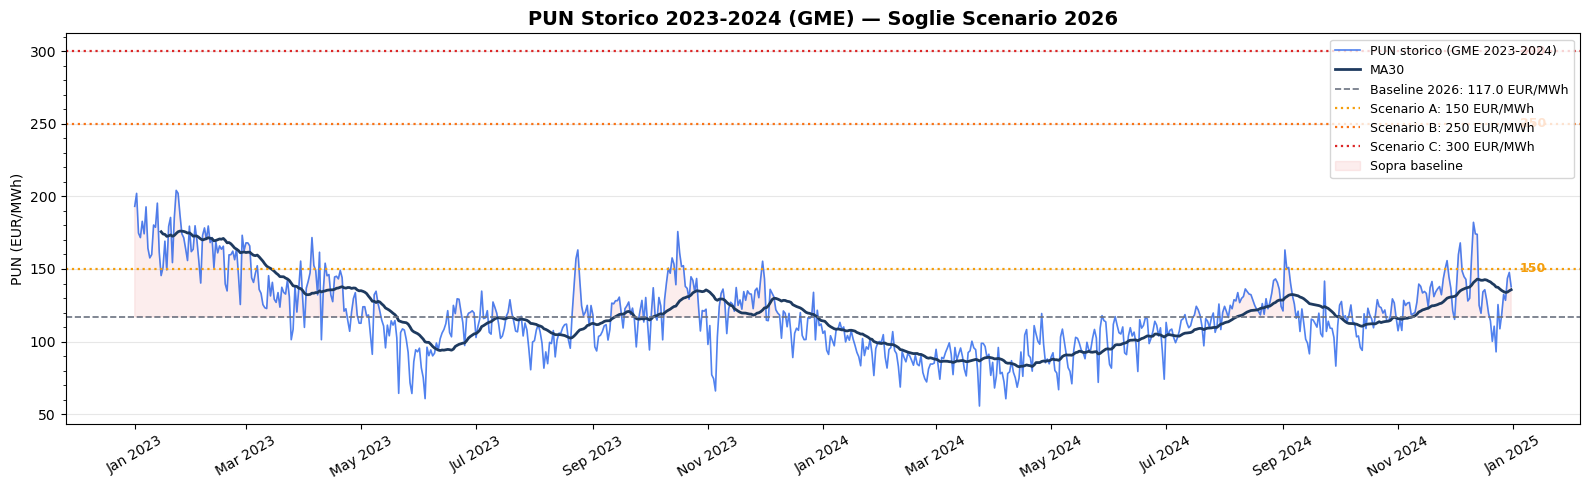


PUN storico — mean: 117.9  min: 55.7  max: 204.1  EUR/MWh
Giorni sopra baseline (117.0 EUR/MWh): 351 / 731


In [5]:
# --- Phase C: Historical PUN chart + scenario lines ---

SCENARIO_COLORS = {
    'A — Tensione lieve'  : '#f59e0b',
    'B — Shock moderato'  : '#f97316',
    'C — Shock severo'    : '#dc2626',
}

fig, ax = plt.subplots(figsize=(16, 5))

# Historical PUN (daily)
ax.plot(dim_energy['date'], dim_energy['pun_eur_mwh'],
        color='#2563eb', linewidth=1.2, alpha=0.8, label='PUN storico (GME 2023-2024)')

# MA30 smoothing
pun_ma30 = dim_energy['pun_eur_mwh'].rolling(30, min_periods=15).mean()
ax.plot(dim_energy['date'], pun_ma30,
        color='#1e3a5f', linewidth=2.0, label='MA30')

# Baseline
ax.axhline(BASELINE_PUN, color='#6b7280', linewidth=1.2, linestyle='--',
           label=f'Baseline 2026: {BASELINE_PUN} EUR/MWh')

# Scenario thresholds
for label, pun in SCENARIOS.items():
    color = SCENARIO_COLORS[label]
    ax.axhline(pun, color=color, linewidth=1.6, linestyle=':',
               label=f'Scenario {label[0]}: {pun} EUR/MWh')
    ax.annotate(f'{pun}', xy=(dim_energy['date'].max(), pun),
                xytext=(6, 0), textcoords='offset points',
                fontsize=9, color=color, va='center', fontweight='bold')

# Shade zone above baseline
ax.fill_between(dim_energy['date'], BASELINE_PUN, dim_energy['pun_eur_mwh'],
                where=(dim_energy['pun_eur_mwh'] > BASELINE_PUN),
                alpha=0.08, color='#dc2626', label='Sopra baseline')

ax.set_title('PUN Storico 2023-2024 (GME) — Soglie Scenario 2026',
             fontsize=14, fontweight='bold')
ax.set_ylabel('PUN (EUR/MWh)')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.get_xticklabels(), rotation=30)
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
plt.tight_layout()
plt.show()

print(f'\nPUN storico — mean: {dim_energy["pun_eur_mwh"].mean():.1f}  '
      f'min: {dim_energy["pun_eur_mwh"].min():.1f}  '
      f'max: {dim_energy["pun_eur_mwh"].max():.1f}  EUR/MWh')
print(f'Giorni sopra baseline ({BASELINE_PUN} EUR/MWh): '
      f'{(dim_energy["pun_eur_mwh"] > BASELINE_PUN).sum()} / {len(dim_energy)}')

---
## Phase D — Demand Response

Extend the pass-through chain to estimate cover loss and total P&L impact  
for two restaurant archetypes: **Turistico** (low price sensitivity)  
and **Locals** (medium-high price sensitivity).

**Segment parameters:**

| Segment | Elasticity (ε) | PT rate consigliato | Rationale |
|---------|---------------|--------------------|-----------|
| Turistico | −0.25 (range 0.20–0.30) | 0.050 | Tollera aumenti — trasferisci al menu |
| Locals    | −0.70 (range 0.60–0.80) | 0.015 | Price-sensitive — assorbi nel margine |

**Extended chain (per segment):**
```
Δ_menu_seg      = Δ_energy × PT_seg
covers_loss_pct = |ε_seg| × Δ_menu_seg
covers_loss_day = covers_mean × covers_loss_pct
revenue_loss    = covers_loss_day × avg_check
margin_comp_total = energy_cost_increase
                  - (revenue_mean × Δ_menu_seg)   # quota trasferita
                  + revenue_loss                   # ricavi persi da domanda
```

### Limiti del modello

1. **Elasticità stimate, non calibrate su dati reali.**  
   Valori da letteratura HoReCa (turistico ε≈0.25, locals ε≈0.70).  
   In produzione: calibrare su dati reali con regressione `covers ~ delta_menu_pct`.

2. **Labour cost escluso dalla catena** — tipicamente 28–35% del fatturato,  
   principale leva di risposta operativa insieme al menu engineering.  
   Da includere in una versione avanzata del modello.

3. **Price transition management:** il cambio prezzi è immediato tecnicamente,  
   ma richiede gestione attiva della customer experience durante la transizione  
   (formazione sala, compensazioni selettive) per non perdere clientela fidelizzata.  
   La matrice ME è costruibile sui dati POS esistenti.

4. **Elasticità non lineare e multi-fattoriale:** nella realtà ε varia con  
   il livello di prezzo, ma anche con la composizione del menu, la qualità  
   percepita del servizio e la disponibilità di alternative nella zona.  
   Il prezzo è solo una delle leve — menu engineering e service quality  
   influenzano la domanda in modo indipendente dal pricing.


In [ ]:
# --- Phase D: Demand Response — segment parameters ---

SEGMENTS = {
    "Turistico": {
        "elasticity" : 0.25,    # |ε| midpoint 0.20–0.30
        "pt_rate"    : 0.050,   # higher PT: tourist tolerates menu price increase
        "color"      : "#2563eb",
    },
    "Locals": {
        "elasticity" : 0.70,    # |ε| midpoint 0.60–0.80
        "pt_rate"    : 0.015,   # lower PT: absorb more to retain regulars
        "color"      : "#059669",
    },
}

COVERS_MEAN = df["covers"].mean()
AVG_CHECK   = df["avg_check"].mean()

print(f"Covers mean : {COVERS_MEAN:.1f} covers/day")
print(f"Avg check   : {AVG_CHECK:.2f} EUR/cover")
print(f"Revenue mean: {REVENUE_MEAN:.2f} EUR/day")
print()

# --- Computation: scenario × segment ---
rows_d = []

for scen_label, pun in SCENARIOS.items():
    delta_energy         = (pun - BASELINE_PUN) / BASELINE_PUN
    energy_cost_increase = REVENUE_MEAN * ENERGY_SHARE * delta_energy

    for seg_name, seg in SEGMENTS.items():
        delta_menu_seg    = delta_energy * seg["pt_rate"]
        covers_loss_pct   = seg["elasticity"] * delta_menu_seg
        covers_loss_day   = COVERS_MEAN * covers_loss_pct
        revenue_loss_day  = covers_loss_day * AVG_CHECK
        quota_trasferita  = REVENUE_MEAN * delta_menu_seg
        margin_comp_total = energy_cost_increase - quota_trasferita + revenue_loss_day
        margin_comp_year  = margin_comp_total * 365

        rows_d.append({
            "scenario"         : scen_label,
            "pun"              : pun,
            "segment"          : seg_name,
            "delta_energy_pct" : round(delta_energy * 100, 1),
            "delta_menu_pct"   : round(delta_menu_seg * 100, 2),
            "covers_loss_pct"  : round(covers_loss_pct * 100, 2),
            "covers_loss_day"  : round(covers_loss_day, 1),
            "revenue_loss_day" : round(revenue_loss_day, 0),
            "quota_trasferita" : round(quota_trasferita, 0),
            "margin_comp_day"  : round(margin_comp_total, 0),
            "margin_comp_year" : round(margin_comp_year, 0),
        })

results_d = pd.DataFrame(rows_d)
print("Computation complete — results_d shape:", results_d.shape)


In [ ]:
# --- Phase D: Per-scenario summary + operational levers ---

LEVERS = {
    "A": {
        "urgency": "Bassa urgenza — monitoraggio attivo",
        "actions": [
            ("Ottimizzazione turni staff",  "1-2 giorni",    "costo orario medio per coperto",
             "Analisi presenze per fascia oraria; ridurre ore nelle fasce sotto soglia"),
            ("Menu engineering",            "2-3 giorni",    "penetration rate piatti target",
             "Identificare 3-5 piatti ad alto margine da spingere in carta e in sala"),
            ("Rinegoziazione fornitori",    "1-2 settimane", "prezzo unitario DDT",
             "Benchmark prezzi DDT su top 10 ingredienti; pronto alla trattativa"),
        ]
    },
    "B": {
        "urgency": "Urgenza moderata — risposta attiva entro 2 settimane",
        "actions": [
            ("Ottimizzazione turni staff",  "1-2 giorni",    "costo orario medio per coperto",
             "Ridurre ore nei giorni sotto break-even; revisione contratti part-time"),
            ("Menu engineering",            "2-3 giorni",    "penetration rate piatti target",
             "Revisione carta: aumenti selettivi su 30-40% piatti; eliminare i margine-negativi"),
            ("Rinegoziazione fornitori",    "1-2 settimane", "prezzo unitario DDT",
             "Rinegoziazione attiva top 5 ingredienti per costo; confronto fornitori alternativi"),
        ]
    },
    "C": {
        "urgency": "Alta urgenza — piano d'azione immediato",
        "actions": [
            ("Ottimizzazione turni staff",  "1-2 giorni",    "costo orario medio per coperto",
             "Restructuring turni; valutare riduzione personale su fasce non redditizie"),
            ("Menu engineering",            "2-3 giorni",    "penetration rate piatti target",
             "Redesign carta: eliminare piatti a margine < 60%; ridurre ampiezza offerta"),
            ("Rinegoziazione fornitori",    "1-2 settimane", "prezzo unitario DDT",
             "Gara fornitori alternativi; contratti a prezzo fisso su commodity critiche"),
        ]
    },
}

for scen_label, pun in SCENARIOS.items():
    scen_key  = scen_label[0]
    lever     = LEVERS[scen_key]
    scen_rows = results_d[results_d["scenario"] == scen_label]

    print("=" * 70)
    print(f"  Scenario {scen_label}  ({pun} EUR/MWh)")
    print(f"  {lever['urgency']}")
    print("=" * 70)

    for _, row in scen_rows.iterrows():
        print(f"\n  [{row['segment']}]")
        print(f"    Δ% energia              : +{row['delta_energy_pct']:.1f}%")
        print(f"    Δ% prezzo menu          : +{row['delta_menu_pct']:.2f}%")
        print(f"    Coperti persi/giorno    :  {row['covers_loss_day']:.1f}  ({row['covers_loss_pct']:.2f}% domanda)")
        print(f"    Revenue persa/giorno    :  {row['revenue_loss_day']:.0f} EUR")
        print(f"    Quota trasferita/giorno :  {row['quota_trasferita']:.0f} EUR")
        print(f"    Compressione margine    :  {row['margin_comp_day']:.0f} EUR/day  ({row['margin_comp_year']:,.0f} EUR/anno)")

    print("\n  Leve operative:")
    for leva, timeframe, kpi, note in lever["actions"]:
        print(f"    > {leva:<30} [{timeframe:<14}]  KPI: {kpi}")
        print(f"      {note}")
    print()


In [ ]:
# --- Phase D: Comparative table + chart ---

print("COMPARATIVE TABLE — Segment x Scenario")
display(results_d[[
    "scenario", "pun", "segment",
    "delta_menu_pct", "covers_loss_day", "covers_loss_pct",
    "quota_trasferita", "revenue_loss_day", "margin_comp_day", "margin_comp_year"
]].rename(columns={
    "scenario"         : "Scenario",
    "pun"              : "PUN",
    "segment"          : "Segment",
    "delta_menu_pct"   : "Δ% menu",
    "covers_loss_day"  : "Cop. persi/g",
    "covers_loss_pct"  : "Cop. loss%",
    "quota_trasferita" : "Trasferito EUR/g",
    "revenue_loss_day" : "Rev. loss EUR/g",
    "margin_comp_day"  : "Comp. EUR/g",
    "margin_comp_year" : "Comp. EUR/anno",
}))

# --- Grouped bar chart ---
turistico_vals = results_d[results_d["segment"] == "Turistico"]["margin_comp_day"].values
locals_vals    = results_d[results_d["segment"] == "Locals"]["margin_comp_day"].values
scen_labels    = [f"{s[0]}\n{p} EUR/MWh" for s, p in
                  zip(results_d["scenario"].unique(), results_d["pun"].unique())]
ref_vals       = results["margin_comp_eur_day"].values

x     = np.arange(len(SCENARIOS))
width = 0.30

fig, ax = plt.subplots(figsize=(12, 5))

bars_t = ax.bar(x - width, turistico_vals, width,
                color="#2563eb", alpha=0.85, label="Turistico")
bars_l = ax.bar(x,          locals_vals,   width,
                color="#059669", alpha=0.85, label="Locals")
bars_b = ax.bar(x + width,  ref_vals,      width,
                color="#dc2626", alpha=0.55, label="Phase B — no demand response")

for bars in [bars_t, bars_l, bars_b]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
                f"{bar.get_height():.0f}",
                ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(scen_labels, fontsize=11)
ax.set_ylabel("Compressione margine (EUR/day)")
ax.set_title(
    "Phase D — Compressione Margine Totale: Segmento x Scenario\n"
    "(energy cost increase − quota trasferita + revenue persa da domanda)",
    fontsize=13, fontweight="bold"
)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nStrategia consigliata per segmento:")
print("  Turistico — priorita' al pass-through: aumenti menu selettivi preservano margine")
print("  Locals    — priorita' al menu engineering + fornitori: minimizzare impatto prezzo visibile")


---
## Closing Remarks

The energy shock is real and current. The situation does not appear to be changing,  
and this notebook presents three scenarios — from the most plausible to the most extreme.

Depending on what kind of restaurant you run, you may find yourself caught in these dynamics —  
and more importantly, you may be forced to reckon with your customer base.  
**Are they tourists? Are they locals?**

One thing is certain: looking at how the sector has reacted in the past,  
you cannot pass 100% of the cost increases on to your customers.  
**You will have to sacrifice your margin.**

And here is the question that matters most:  
*Are your margins already healthy enough to absorb this hit — or are you already losing money?*

---

### Margin compression at a glance

| Scenario | PUN | Turistico | Locals |
|----------|-----|-----------|--------|
| A — Mild tension | 150 €/MWh | ~45 EUR/day &nbsp; (~16,400 EUR/year) | ~63 EUR/day &nbsp; (~23,000 EUR/year) |
| B — Moderate shock | 250 €/MWh | ~181 EUR/day &nbsp; (~66,100 EUR/year) | ~254 EUR/day &nbsp; (~92,700 EUR/year) |
| C — Severe shock | 300 €/MWh | ~249 EUR/day &nbsp; (~90,900 EUR/year) | ~349 EUR/day &nbsp; (~127,400 EUR/year) |

> *Figures based on: revenue mean 1,940 EUR/day · energy share 12% · pass-through rate 0.025 (FIPE 2022 calibration).*  
> *Demand response modelled with price elasticity: Turistico ε = −0.25 · Locals ε = −0.70.*  
> *Labour cost not included — see model limitations above.*
